# Content Analysis

Content analysis of Bluesky discourse around machine translation (MT).

Complements the network analysis in `analysis.ipynb` — this notebook looks at
*what* people say, not *who* talks to whom.

**Research questions** (same as the network analysis):
1. **Sentiment & framing** — Do people talk about MT as a tool, a threat, or both?
2. **Professional impact discourse** — How do working translators discuss MT's effect on their careers?
3. **Utility vs. displacement tension** — Do people acknowledge MT's utility while lamenting professional erosion?


## Setup

In [1]:
!pip -q install vaderSentiment nrclex spacy wordcloud
!python3 -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nrclex import NRCLex
import spacy
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', 120)

In [3]:
DATA_DIR = 'data/'

df = pd.read_csv(DATA_DIR + 'posts_clean.csv')
df['created_at'] = pd.to_datetime(df['created_at'], format='mixed', utc=True)

print(f"Posts loaded: {len(df)}")
print(f"Date range: {df['created_at'].min()} → {df['created_at'].max()}")
print(df['user_type'].value_counts())

Posts loaded: 3767
Date range: 2025-06-27 06:01:08+00:00 → 2026-06-26 13:55:08+00:00
user_type
general         3118
professional     530
tech             119
Name: count, dtype: int64


## Sentiment Analysis

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner), a lexicon- and
rule-based model tuned for social media text (handles negation, punctuation
emphasis, emoticons, intensifiers). Each post gets a `compound` score in
[-1, 1], which we bucket into positive / neutral / negative following VADER's
standard thresholds.

In [4]:
analyzer = SentimentIntensityAnalyzer()

def vader_compound(text):
    return analyzer.polarity_scores(str(text))['compound']

df['sentiment_compound'] = df['text_clean'].apply(vader_compound)

def bucket_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    return 'neutral'

df['sentiment'] = df['sentiment_compound'].apply(bucket_sentiment)
df['sentiment'].value_counts()

sentiment
positive    1924
negative    1047
neutral      796
Name: count, dtype: int64

### RQ1 — Tool or threat? Overall framing

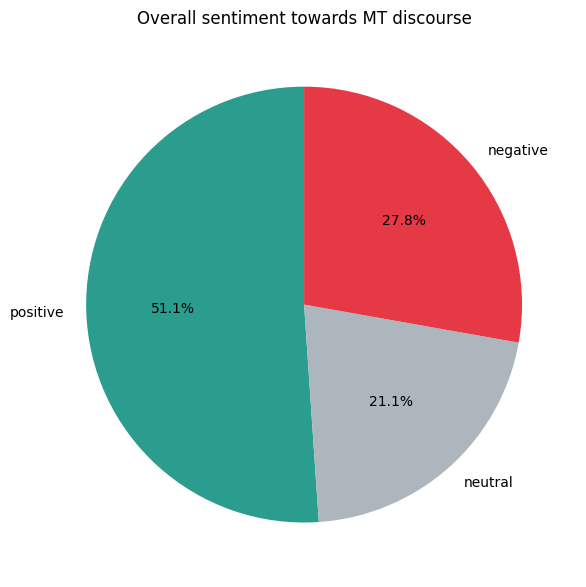

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = df['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
colors = {'positive': '#2a9d8f', 'neutral': '#adb5bd', 'negative': '#e63946'}
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=[colors[c] for c in counts.index], startangle=90)
ax.set_title('Overall sentiment towards MT discourse')
plt.tight_layout()
plt.savefig(DATA_DIR + 'sentiment_overall.png', dpi=150, bbox_inches='tight')
plt.show()

### RQ2/RQ3 — Sentiment by user type

If professionals (translators) are more negative than the general public,
that supports the "displacement" framing; if they're similarly positive,
that supports "MT as a useful tool" even among those most affected.

sentiment     positive  neutral  negative
user_type                                
general          0.503    0.221     0.276
professional     0.568    0.158     0.274
tech             0.471    0.193     0.336


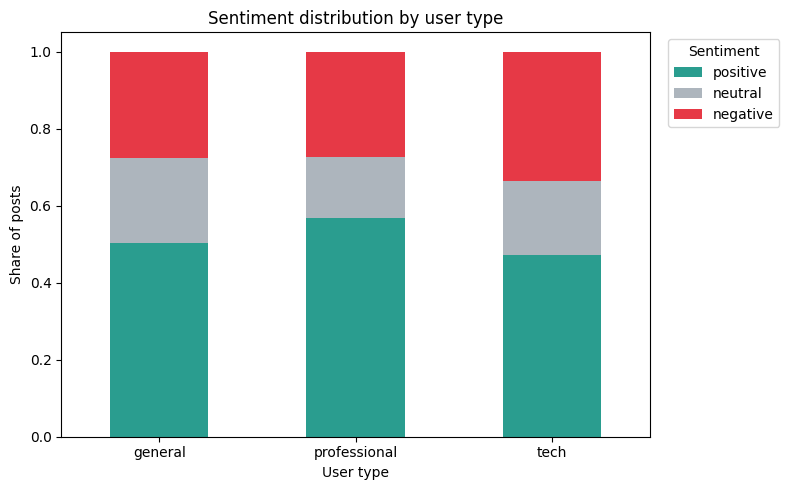

In [6]:
sentiment_by_type = pd.crosstab(df['user_type'], df['sentiment'], normalize='index')
sentiment_by_type = sentiment_by_type.reindex(columns=['positive', 'neutral', 'negative'])
print(sentiment_by_type.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
sentiment_by_type.plot(kind='bar', stacked=True, color=[colors[c] for c in sentiment_by_type.columns], ax=ax)
ax.set_ylabel('Share of posts')
ax.set_xlabel('User type')
ax.set_title('Sentiment distribution by user type')
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DATA_DIR + 'sentiment_by_user_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
mean_compound_by_type = df.groupby('user_type')['sentiment_compound'].agg(['mean', 'median', 'count'])
print(mean_compound_by_type.round(3))

               mean  median  count
user_type                         
general       0.138   0.052   3118
professional  0.196   0.266    530
tech          0.097   0.000    119


### Sentiment over time

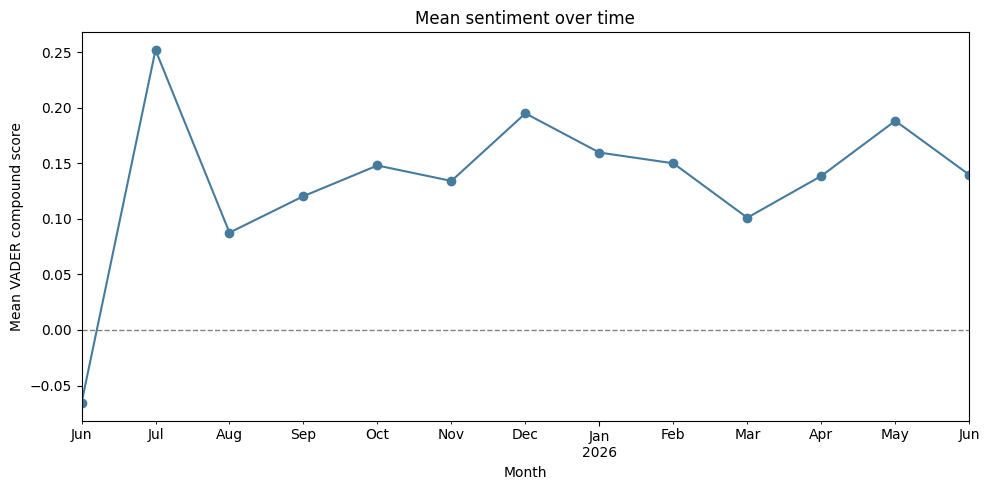

In [8]:
df['month'] = df['created_at'].dt.tz_convert(None).dt.to_period('M').dt.to_timestamp()
monthly_sentiment = df.groupby('month')['sentiment_compound'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_sentiment.plot(ax=ax, marker='o', color='#457b9d')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Mean VADER compound score')
ax.set_xlabel('Month')
ax.set_title('Mean sentiment over time')
plt.tight_layout()
plt.savefig(DATA_DIR + 'sentiment_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Emotion Analysis

We use **NRCLex**, a dictionary-based emotion lexicon (Plutchik's 8 basic
emotions + positive/negative), to see *which* emotions dominate the
discourse beyond simple polarity — e.g. distinguishing "fear" (job loss)
from "anger" (quality complaints) or "trust"/"anticipation" (adoption).

In [9]:
EMOTIONS = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'joy']

def get_emotion_scores(text):
    obj = NRCLex()
    obj.load_raw_text(str(text))
    freqs = obj.affect_frequencies
    return pd.Series({e: freqs.get(e, 0.0) for e in EMOTIONS})

emotion_scores = df['text_clean'].apply(get_emotion_scores)
df = pd.concat([df, emotion_scores], axis=1)
df[EMOTIONS].mean().sort_values(ascending=False)

trust           0.261697
anticipation    0.067009
fear            0.040465
sadness         0.038509
joy             0.037878
anger           0.029838
disgust         0.023840
surprise        0.023813
dtype: float64

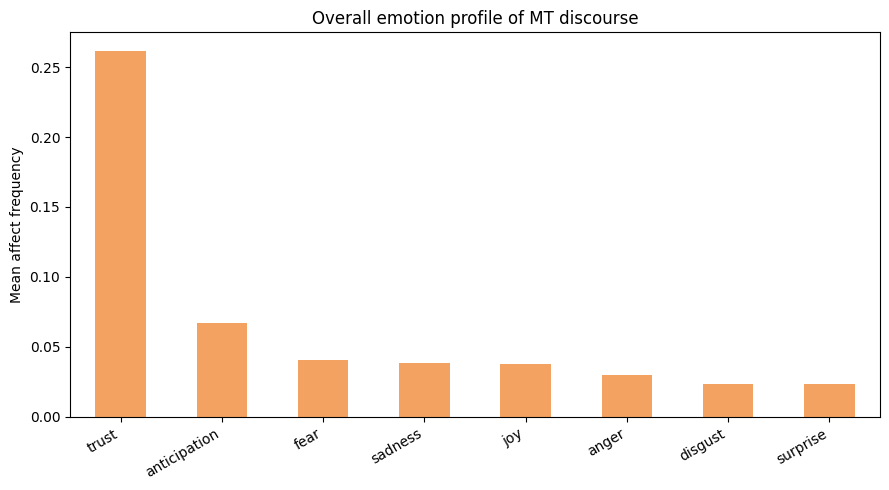

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
overall_emotions = df[EMOTIONS].mean().sort_values(ascending=False)
overall_emotions.plot(kind='bar', color='#f4a261', ax=ax)
ax.set_ylabel('Mean affect frequency')
ax.set_title('Overall emotion profile of MT discourse')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR + 'emotion_overall.png', dpi=150, bbox_inches='tight')
plt.show()

### Emotion profile by user type

A radar-style comparison: do professionals show more fear/anger about MT
than the general public or tech users?

               fear  anger  anticipation  trust  surprise  sadness  disgust  \
user_type                                                                     
general       0.041  0.031         0.068  0.263     0.024    0.038    0.024   
professional  0.039  0.026         0.066  0.257     0.023    0.043    0.020   
tech          0.035  0.025         0.056  0.245     0.023    0.043    0.028   

                joy  
user_type            
general       0.039  
professional  0.031  
tech          0.042  


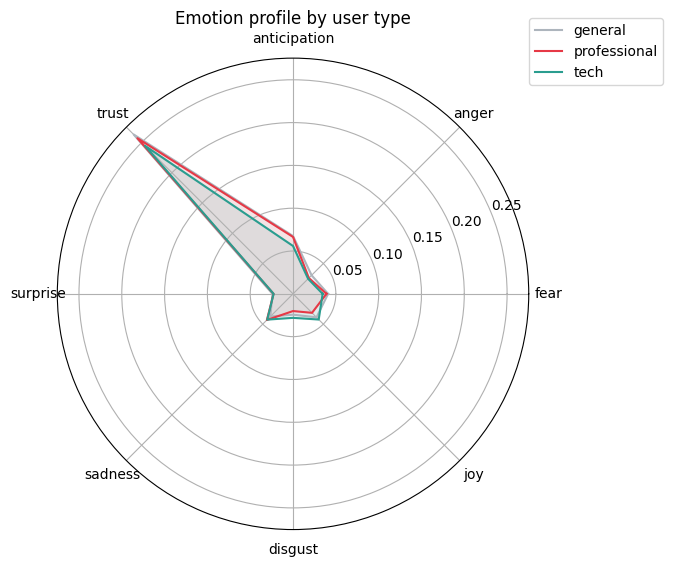

In [11]:
emotion_by_type = df.groupby('user_type')[EMOTIONS].mean()
print(emotion_by_type.round(3))

angles = np.linspace(0, 2 * np.pi, len(EMOTIONS), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
type_colors = {'professional': '#e63946', 'general': '#adb5bd', 'tech': '#2a9d8f'}

for utype, row in emotion_by_type.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=utype, color=type_colors.get(utype, '#333'))
    ax.fill(angles, values, alpha=0.1, color=type_colors.get(utype, '#333'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(EMOTIONS)
ax.set_title('Emotion profile by user type')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(DATA_DIR + 'emotion_by_user_type.png', dpi=150, bbox_inches='tight')
plt.show()

## Named Entity Recognition

We use **spaCy**'s pretrained English pipeline to extract named entities from
post text — mainly `ORG` (companies/tools like DeepL, Google Translate) and
`PRODUCT`, to see which specific MT tools/players dominate the conversation.

In [12]:
nlp = spacy.load('en_core_web_sm', disable=['parser'])

ENTITY_LABELS = {'ORG', 'PRODUCT', 'PERSON', 'GPE'}

def extract_entities(text):
    doc = nlp(str(text))
    return [(ent.text, ent.label_) for ent in doc.ents if ent.label_ in ENTITY_LABELS]

df['entities'] = df['text_clean'].apply(extract_entities)
all_entities = [ent for ents in df['entities'] for ent in ents]
print(f"Entities extracted: {len(all_entities)}")

Entities extracted: 5481


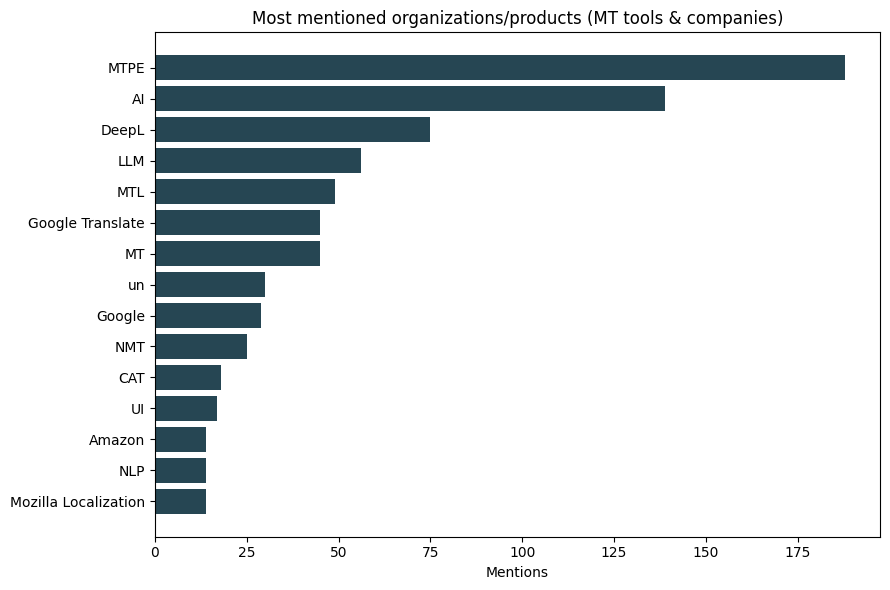

In [13]:
entity_counts = Counter(text.strip() for text, label in all_entities if label in ('ORG', 'PRODUCT'))
top_entities = entity_counts.most_common(15)

fig, ax = plt.subplots(figsize=(9, 6))
labels, values = zip(*top_entities)
ax.barh(labels[::-1], values[::-1], color='#264653')
ax.set_xlabel('Mentions')
ax.set_title('Most mentioned organizations/products (MT tools & companies)')
plt.tight_layout()
plt.savefig(DATA_DIR + 'top_entities.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
entity_label_counts = Counter(label for _, label in all_entities)
print("Entity type breakdown:")
for label, count in entity_label_counts.most_common():
    print(f"  {label:<10} {count}")

Entity type breakdown:
  ORG        2497
  PERSON     1894
  GPE        966
  PRODUCT    124


## Word clouds by sentiment

A quick qualitative view of vocabulary associated with positive vs. negative
posts (same idea as the `#FlatEarth` example in the project brief).

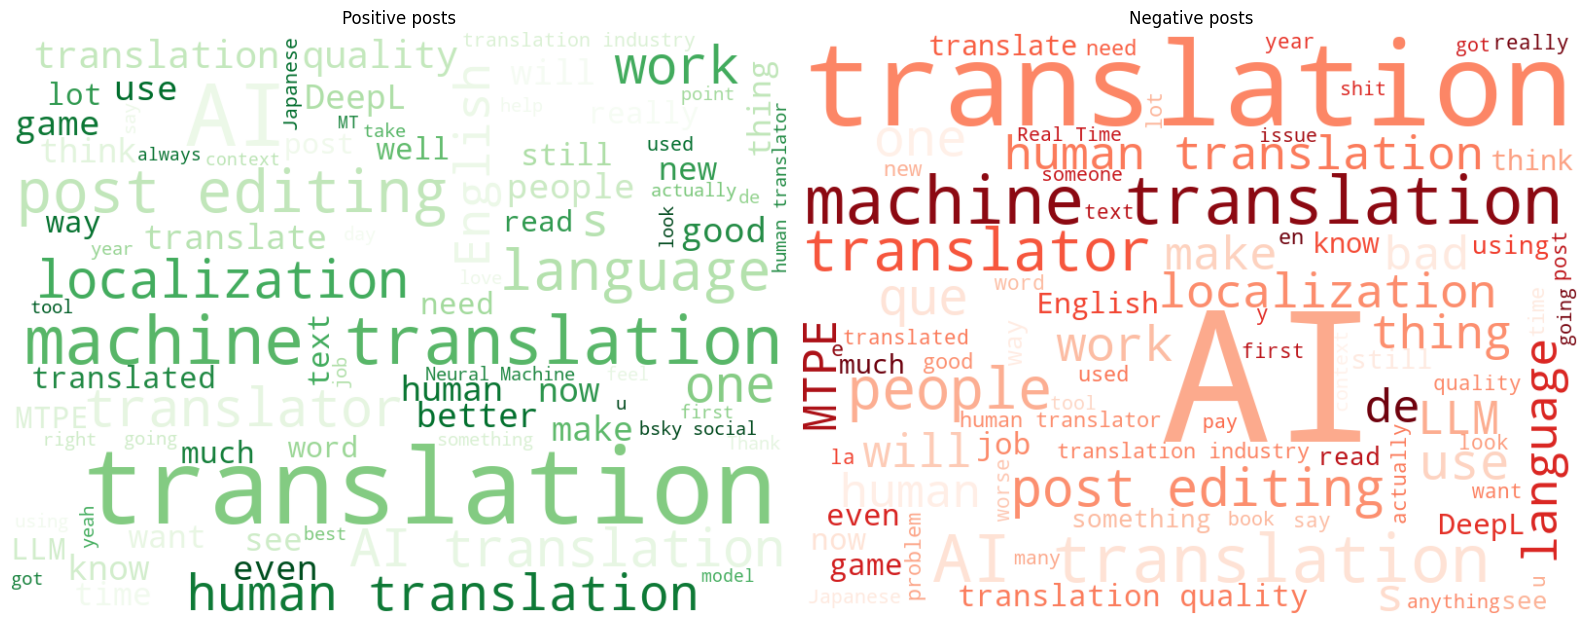

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, sentiment_label, cmap in zip(axes, ['positive', 'negative'], ['Greens', 'Reds']):
    text = ' '.join(df.loc[df['sentiment'] == sentiment_label, 'text_clean'].astype(str))
    wc = WordCloud(width=800, height=600, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment_label.capitalize()} posts')
    ax.axis('off')

plt.tight_layout()
plt.savefig(DATA_DIR + 'wordclouds_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

- Save the enriched dataset (with sentiment, emotion, and entity columns) for
  use in the final report.

In [16]:
cols_to_save = ['uri', 'handle', 'user_type', 'created_at', 'text_clean',
                'sentiment_compound', 'sentiment'] + EMOTIONS + ['entities']
df[cols_to_save].to_csv(DATA_DIR + 'posts_content_analysis.csv', index=False)
print(f"Saved posts_content_analysis.csv — {len(df)} posts")

Saved posts_content_analysis.csv — 3767 posts
